In [1]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

from xaikd import utils

In [2]:
api = wandb.Api()

In [3]:
EXPERIMENT_GROUP = "./artifacts/2023-10-s17/experiments/ex2.2-distill-under-data-scarcity--varying-ts-clv-fixscale-logitmodwinner"

In [4]:
def compression_ratio(teacher, student, num_classes=5, verbose=False):
    
    total_teacher_params, _ = utils.count_params_in_model(models.get_trained_model(teacher))
    total_student_params, _ = utils.count_params_in_model(
        models.get_untrained_model(student, num_classes=num_classes)
    )
    
    compr_ratio = total_teacher_params / total_student_params
    
    if verbose:
        
        print(f"teacher={teacher}; student={student}: compr_ratio={compr_ratio}")

    return compr_ratio
    
compression_ratio("cifar100-resnet18-v1", "resnet18xscifarcompr4", verbose=True)

teacher=cifar100-resnet18-v1; student=resnet18xscifarcompr4: compr_ratio=368.9255252687995


368.9255252687995

In [5]:
def read_data(
    teacher,
    arr_students,
    policies,
    lambda_task,
    lambda_kd,
    training_size,
    contamination_level,
    verbose=False,
    learning_bases_from_clean_data=False
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep3',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": {"$in": arr_students}},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": {"$in": policies}},
            {"config.training_size": training_size},
            {"config.contamination_level": contamination_level},
            {"config.learning_bases_from_clean_data": learning_bases_from_clean_data}
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    for run in runs:
        seed = run.config["seed"]
         
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        rows.append(
            dict(
                best_epoch=k,
                seed=seed,
                teacher=run.config["teacher"],
                student=run.config["student"],
                policy=run.config["policy"],
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["policy_lambda_layer"],
                training_size=run.config["training_size"],
                contamination_level=run.config["contamination_level"],

                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
            )
        )

    
    
    
    df = pd.DataFrame(rows)

      
    df = df.groupby(by=["teacher", "student", "policy", "contamination_level"]).agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    
    df["compression_ratio"] = df.apply(
        lambda r: compression_ratio(r["teacher"][0], r["student"][0]),
        axis=1
    )
    
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        3,
        err_msg="number of count should eqalt to the number of CIFAR100 superclasses"
    )
    
    np.testing.assert_allclose(
        df["teacher_acc"]["mean"].values,
        df["teacher_acc"]["mean"].values[0]
    )

    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-v1",
    arr_students=[
        "resnet18xscifarcompr1",
        "resnet18xscifarcompr2",
        "resnet18xscifarcompr4"
    ],
    policies = [ 
        "nothing",
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "basis-identity:random--uncentered",
#         "vid",
#         "attention-transfer",
    ],
    training_size=0.1,
    contamination_level=0.25,
    
    lambda_task=0.0,
    lambda_kd=1.0,
    learning_bases_from_clean_data=False,
    verbose=True,
)

summary

we have 36 runs
df.shape: (12, 15)


teacher                student  \
                                                  
0   cifar100-resnet18-v1  resnet18xscifarcompr1   
1   cifar100-resnet18-v1  resnet18xscifarcompr1   
2   cifar100-resnet18-v1  resnet18xscifarcompr1   
3   cifar100-resnet18-v1  resnet18xscifarcompr1   
4   cifar100-resnet18-v1  resnet18xscifarcompr2   
5   cifar100-resnet18-v1  resnet18xscifarcompr2   
6   cifar100-resnet18-v1  resnet18xscifarcompr2   
7   cifar100-resnet18-v1  resnet18xscifarcompr2   
8   cifar100-resnet18-v1  resnet18xscifarcompr4   
9   cifar100-resnet18-v1  resnet18xscifarcompr4   
10  cifar100-resnet18-v1  resnet18xscifarcompr4   
11  cifar100-resnet18-v1  resnet18xscifarcompr4   

                                     policy contamination_level   val_acc  \
                                                                     mean   
0            basis-identity:pca--uncentered                0.25  0.475333   
1   basis-identity:prca-sortabs--uncentered                0.25  0.470000   
2         basis-identity:random--uncentered                0.25  0.472000   
3                                   nothing                0.25  0.373333   
4            basis-identity:pca--uncentered                0.25  0.427333   
5   basis-identity:prca-sortabs--uncentered                0.25  0.418667   
6         basis-identity:random--uncentered                0.25  0.390667   
7                                   nothing                0.25  0.365333   
8            basis-identity:pca--uncentered                0.25  0.348000   
9   basis-identity:prca-sortabs--uncentered                0.25  0.370667   
10        basis-identity:random--uncentered                0.25  0.314000   
11                                  nothing                0.25  0.332000   

                   val_agreement                  \
         std count          mean       std count   
0   0.033486     3      0.504667  0.027154     3   
1   0.014000     3      0.488000  0.019079     3   
2   0.024249     3      0.482667  0.025403     3   
3   0.009019     3      0.348667  0.003055     3   
4   0.005033     3      0.438000  0.008718     3   
5   0.028449     3      0.438667  0.015144     3   
6   0.016653     3      0.407333  0.016289     3   
7   0.014468     3      0.340667  0.008083     3   
8   0.017776     3      0.354000  0.014000     3   
9   0.015144     3      0.362000  0.015620     3   
10  0.008718     3      0.313333  0.003055     3   
11  0.019079     3      0.326667  0.021939     3   

   val_agreement_on_teacher_correct                 teacher_acc  \
                               mean       std count        mean   
0                          0.363333  0.020526     3    0.614667   
1                          0.352667  0.013317     3    0.614667   
2                          0.356667  0.027154     3    0.614667   
3                          0.262000  0.008718     3    0.614667   
4                          0.322667  0.003055     3    0.614667   
5                          0.316000  0.019079     3    0.614667   
6                          0.292000  0.014422     3    0.614667   
7                          0.256667  0.009452     3    0.614667   
8                          0.242667  0.019425     3    0.614667   
9                          0.259333  0.016289     3    0.614667   
10                         0.218667  0.010263     3    0.614667   
11                         0.235333  0.015144     3    0.614667   

   compression_ratio  
                      
0          23.625459  
1          23.625459  
2          23.625459  
3          23.625459  
4          93.734656  
5          93.734656  
6          93.734656  
7          93.734656  
8         368.925525  
9         368.925525  
10        368.925525  
11        368.925525

# Comparison on `training-size` and `contamination-level`

working on ts=1.0, ctv=0.0
working on ts=1.0, ctv=0.25
working on ts=1.0, ctv=0.5
working on ts=1.0, ctv=0.75
working on ts=1.0, ctv=1.0


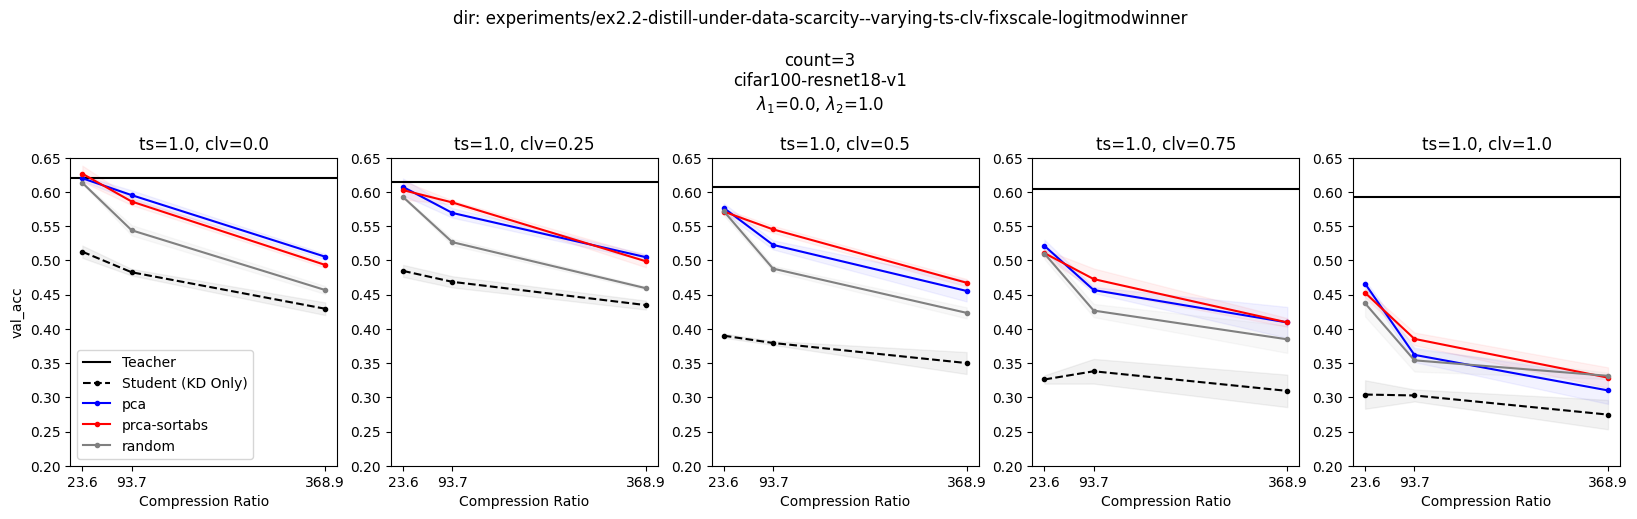

In [6]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "nothing":
        return "--"
    elif policy == "fitnetinvidbnrelu":
        return "-."
    else:
        return "-"
    
def marker(policy, learning_bases_from_clean_data):
    if learning_bases_from_clean_data:
        return "x"
    else:
        return "."

def alias(policy, learning_bases_from_clean_data):
    
    if "basis" in policy:
    
        slug = policy \
            .replace("basis-identity:", "") \
            .replace("--uncentered", "")
        
        if learning_bases_from_clean_data:
            return f"{slug} (from clean ds)"
        else:
            return slug
    
    elif policy == "nothing":
        return "Student (KD Only)"
    
    else:
        return policy

    
def color(policy):
    if "pca" in policy:
        return "blue"
    elif "prca" in policy:
        return "red"
    elif policy == "nothing":
        return "black"
    elif "random" in policy:
        return "gray"
    elif policy == "fitnetinvidinner" or policy == "fitnetinvidbnrelu":
        return plt.gca().lines[-1].get_color()
    else:
        return None
    
def viz_distillation(
    teacher,
    arr_students, 
    policies, 
    training_size,
    arr_contamination_levels,
    show_legend=True,
):
        
    lambda_kd = 1.0
    lambda_task = 0.0
    learning_bases_from_clean_data = False


    col = "val_acc"
    
    ncols = len(arr_contamination_levels)
    nrows = 1
    
    plt.figure(figsize=(4*ncols, 4*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])
    for cix, contamination_level in enumerate(arr_contamination_levels):
        print(f"working on ts={training_size}, ctv={contamination_level}")
        plt.subplot(nrows, ncols, cix+1)
        plt.title(f"ts={training_size}, clv={contamination_level}")
        
        
        df_main = read_data(
            teacher=teacher,
            policies=policies,
            learning_bases_from_clean_data=learning_bases_from_clean_data,
            lambda_task=lambda_task,
            lambda_kd=lambda_kd,
            training_size=training_size,
            contamination_level=contamination_level,
            arr_students=arr_students,
            verbose=False
        )
        for pix, policy in enumerate(policies):
            df = df_main[df_main["policy"] == policy]
            
            ticks = df["compression_ratio"]

            
            # visualize baseline
            if pix == 0:
                plt.axhline(
                    df["teacher_acc"].values[0],
                    color="k",
                    label="Teacher"
                )
                

                plt.ylim(bottom=0.2, top=0.65)

            # here, we take the first value.
            # the query function already checks that the value is expected
            count = df[col]["count"].values[-1]

            mean = df[col]["mean"]
            stderr = df[col]["std"] / (count ** 0.5)

            plt.plot(
                ticks,
                mean,
                marker=marker(policy, learning_bases_from_clean_data),
                label=alias(policy, learning_bases_from_clean_data),
                ls=ls(policy),
                color=color(policy)
            )

            plt.fill_between(
                ticks,
                mean - stderr,
                mean + stderr,
                alpha=0.05,
                color=plt.gca().lines[-1].get_color()
            )

        plt.xlabel("Compression Ratio")
        plt.xticks(ticks)
        if cix==0:
            plt.ylabel(col)

            plt.legend()

    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"count={count}",
            f"{teacher}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
        ]),
        y=1.25,
    )

viz_distillation(
    teacher = "cifar100-resnet18-v1",

    training_size=1.0,
    arr_students=[
        "resnet18xscifarcompr1",
        "resnet18xscifarcompr2",
        "resnet18xscifarcompr4",
    ],
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75, 1.0],
    policies = [ 
        "nothing",
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "basis-identity:random--uncentered",
#         "vid",
#         "attention-transfer",
    ],
) 

working on ts=1.0, ctv=0.0
working on ts=1.0, ctv=0.25
working on ts=1.0, ctv=0.5
working on ts=1.0, ctv=0.75
working on ts=1.0, ctv=1.0
working on ts=0.5, ctv=0.0
working on ts=0.5, ctv=0.25
working on ts=0.5, ctv=0.5
working on ts=0.5, ctv=0.75
working on ts=0.5, ctv=1.0
working on ts=0.25, ctv=0.0
working on ts=0.25, ctv=0.25
working on ts=0.25, ctv=0.5
working on ts=0.25, ctv=0.75
working on ts=0.25, ctv=1.0
working on ts=0.1, ctv=0.0
working on ts=0.1, ctv=0.25
working on ts=0.1, ctv=0.5
working on ts=0.1, ctv=0.75
working on ts=0.1, ctv=1.0


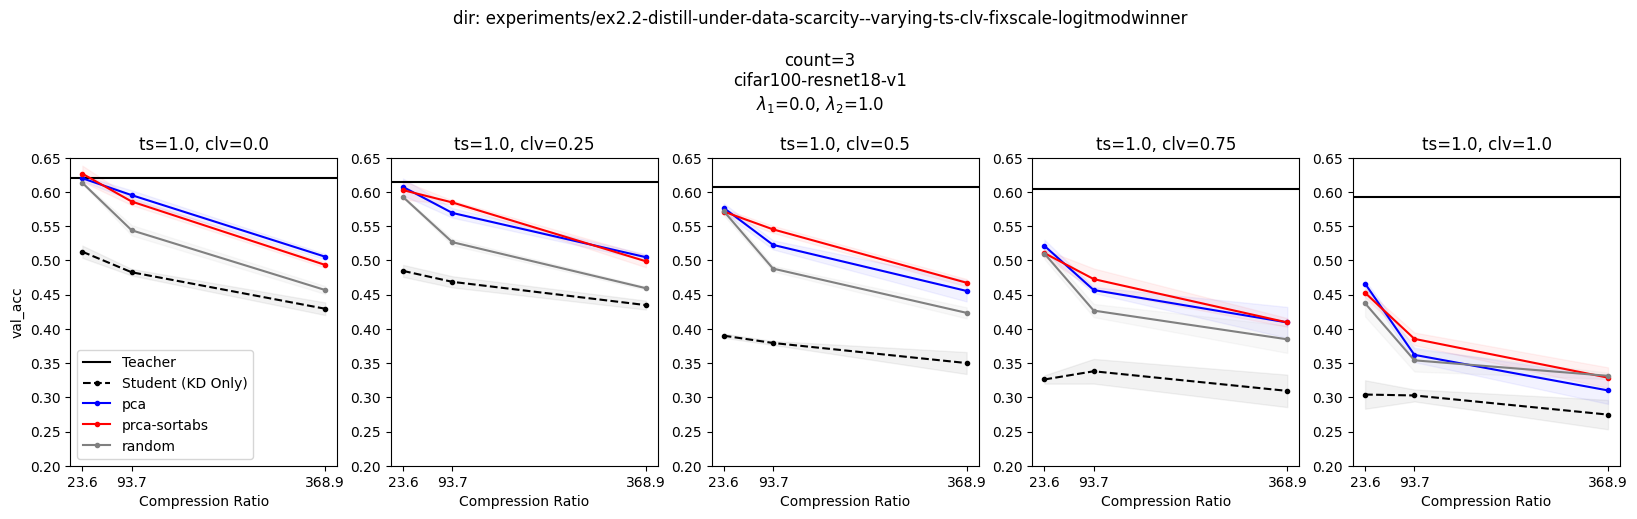

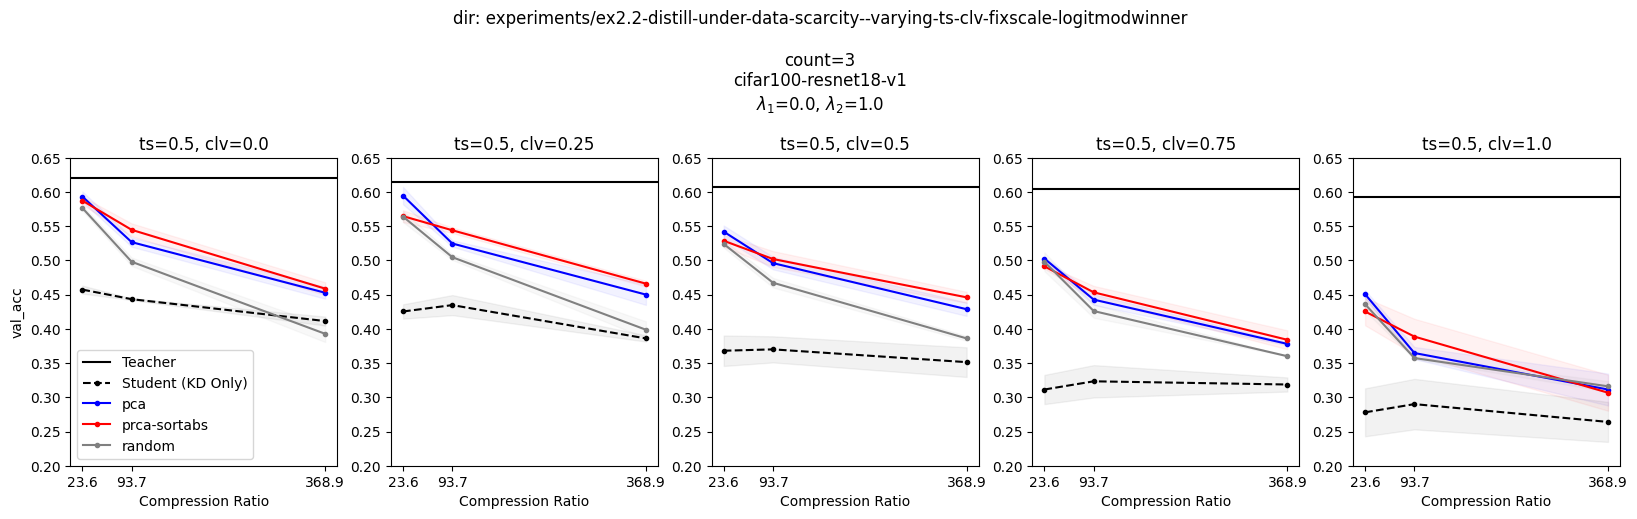

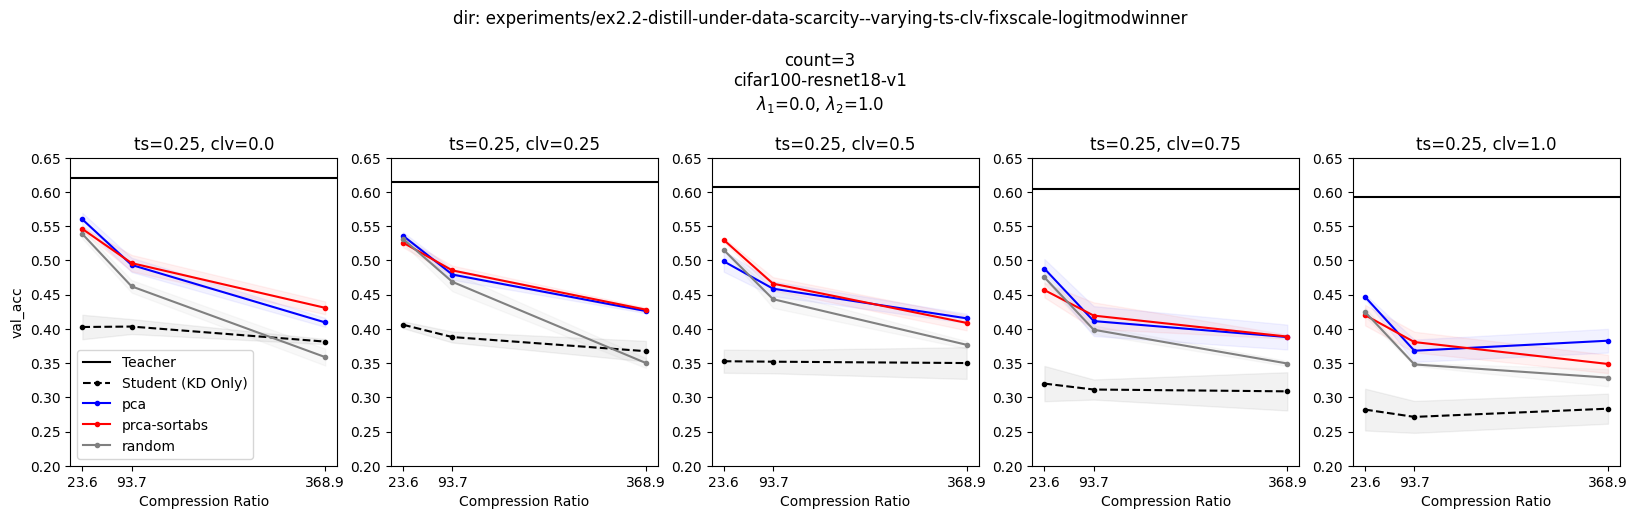

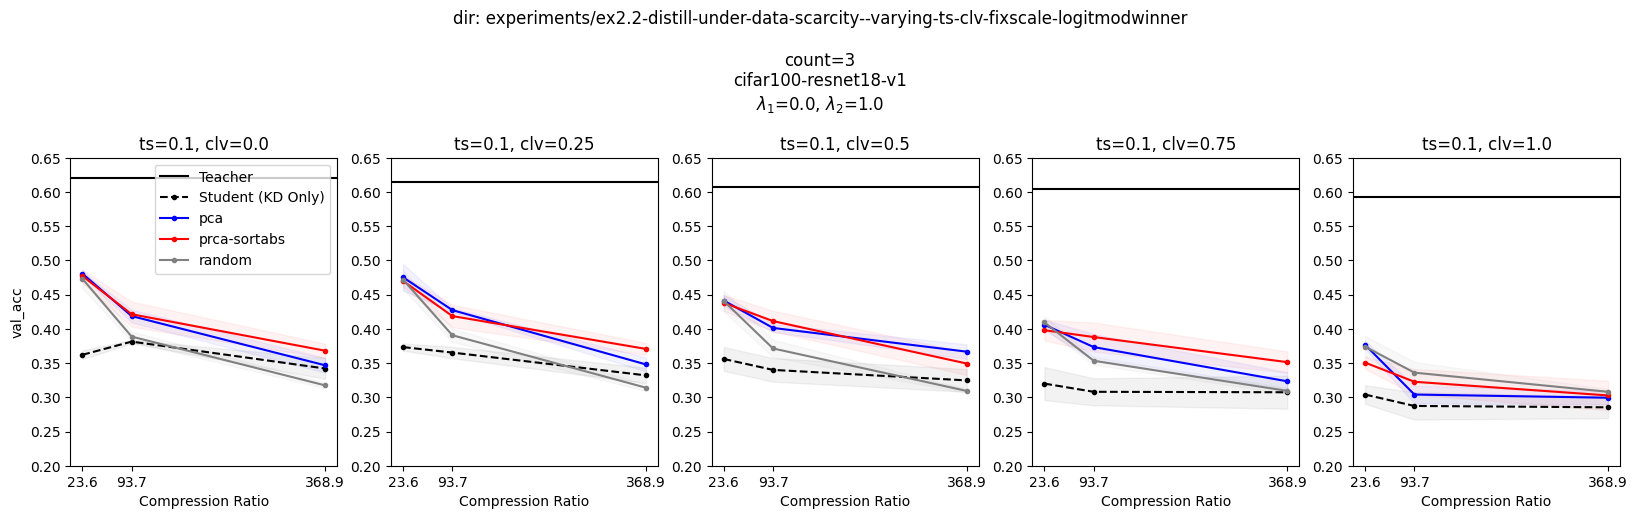

In [7]:
for training_size in [1.0, 0.5, 0.25, 0.1]:

    viz_distillation(
        teacher = "cifar100-resnet18-v1",
        training_size=training_size,
        arr_students=[
            "resnet18xscifarcompr1",
            "resnet18xscifarcompr2",
            "resnet18xscifarcompr4",
        ],
        arr_contamination_levels=[0.0, 0.25, 0.5, 0.75, 1.0],
        policies = [ 
            "nothing",
            "basis-identity:pca--uncentered",
            "basis-identity:prca-sortabs--uncentered",
            "basis-identity:random--uncentered",
#             "vid",
#             "attention-transfer",
        ],
    ) 

# Summary ..


Setup:
<!-- $$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1$ and $\lambda_3$ is set according to the hyperparameter optimization with `contamination-level=0.5` and `training-size=1.0`.
 -->
*Aims:* 
<!-- - investigate the benefit of using PRCA when varying these aspects:
    - the quality of data
    - the quantity of data

    - the size of the student model
 -->
<!-- *Conclusions:*
- So, it seems that `attention-transfer` is still better than `pca` and `prca` when contamination level is 0.75. For other values, `pca` seems to be the  bes


*Further Refinement*: 
- Currently, the $\lambda_3$ is tuned for singla location. We might have to take into account its effect here. -->